In [1]:
import numpy as np
import xarray as xr

In [13]:
# Define path to domain_cfg:
fpath = "/g100_work/optim_IAC/research/noc/otooth/OptimESM/data/CNRM-ESM2-1/Ofx/eORCA1L75_CNRM-ESM2-1.nc"
ds_domain = xr.open_dataset(fpath).rename({"z": "nav_lev"}).drop_vars(["AREA", "VOLUME", "nav_lev"])
ds_domain

<xarray.Dataset> Size: 428MB
Dimensions:       (y: 294, x: 362, nav_lev: 75)
Dimensions without coordinates: y, x, nav_lev
Data variables: (12/43)
    nav_lon       (y, x) float32 426kB ...
    nav_lat       (y, x) float32 426kB ...
    time_counter  float64 8B ...
    tmask         (nav_lev, y, x) int8 8MB ...
    umask         (nav_lev, y, x) int8 8MB ...
    vmask         (nav_lev, y, x) int8 8MB ...
    ...            ...
    gdepv         (nav_lev, y, x) float32 32MB ...
    gdepw_0       (nav_lev, y, x) float32 32MB ...
    gdept_1d      (nav_lev) float64 600B ...
    gdepw_1d      (nav_lev) float64 600B ...
    e3t_1d        (nav_lev) float64 600B ...
    e3w_1d        (nav_lev) float64 600B ...
Attributes:
    file_name:                 mesh_mask.nc
    TimeStamp:                 03/07/2015 08:51:42 -0000
    history:                   Tue Feb 14 08:49:44 2017: ncwa -a t mesh_mask_...
    NCO:                       "4.5.5"
    nco_openmp_thread_number:  1
    Conventions:               CF-1.6

In [14]:
# Define path to gridW file:
fpath = "/g100_work/optim_IAC/research/noc/otooth/OptimESM/data/CNRM-ESM2-1/esm-up2p0/r1i1p2f2/Omon/wo/gn/wo_Omon_CNRM-ESM2-1_02Kpd_r1i1p2f2_gn_185001-187412.nc"
ds_gridW = xr.open_dataset(fpath)

ds_gridW

<xarray.Dataset> Size: 10GB
Dimensions:      (y: 294, x: 362, nvertex: 4, lev: 75, axis_nbounds: 2,
                  time: 300)
Coordinates:
  * lev          (lev) float64 600B 0.0 1.024 2.103 ... 5.596e+03 5.8e+03
  * time         (time) datetime64[ns] 2kB 1850-01-16T12:00:00 ... 1874-12-16...
    lat          (y, x) float64 851kB ...
    lon          (y, x) float64 851kB ...
Dimensions without coordinates: y, x, nvertex, axis_nbounds
Data variables:
    bounds_lon   (y, x, nvertex) float64 3MB ...
    bounds_lat   (y, x, nvertex) float64 3MB ...
    lev_bounds   (lev, axis_nbounds) float64 1kB ...
    time_bounds  (time, axis_nbounds) datetime64[ns] 5kB ...
    wo           (time, lev, y, x) float32 10GB ...
Attributes: (12/51)
    name:                   /scratch/work/bosserti/CMIP6/DECK/AOESM_02Kpd_CM6...
    description:            Created by xios
    Conventions:            CF-1.7 CMIP-6.2
    creation_date:          2025-10-22T08:33:27Z
    title:                  CNRM-ESM2-1 model output prepared for CMIP6 and C...
    activity_id:            CMIP
    ...                     ...
    CMIP6_CV_version:       cv=6.2.3.0-7-g2019642
    dr2xml_md5sum:          9a1fa5cac842f55652e42ad1d6b59c62
    xios_commit:            1442-shuffle
    nemo_gelato_commit:     49095b3accd5d4c_6524fe19b00467a
    arpege_minor_version:   6.3.2
    tracking_id:            hdl:21.14100/dda04ebb-4c47-4fa5-bb83-00e1cd5988c0

In [17]:
wo = ds_gridW['wo'][0, :, :, :].squeeze(drop=True).drop_vars("time").rename({"lev": "nav_lev"})
wmask = 2 + ~np.isnan(wo).drop_vars(["nav_lev", "lat", "lon"]).astype('int8')
wmask.name = "wmask"
wmask.attrs = {}

wmaskutil = wmask[0, :, :]
wmaskutil.name = "wmaskutil"
wmaskutil.attrs = {}

ds_domain["wmask"] = wmask
ds_domain["wmaskutil"] = wmaskutil
ds_domain

<xarray.Dataset> Size: 436MB
Dimensions:       (y: 294, x: 362, nav_lev: 75)
Dimensions without coordinates: y, x, nav_lev
Data variables: (12/45)
    nav_lon       (y, x) float32 426kB ...
    nav_lat       (y, x) float32 426kB ...
    time_counter  float64 8B ...
    tmask         (nav_lev, y, x) int8 8MB ...
    umask         (nav_lev, y, x) int8 8MB ...
    vmask         (nav_lev, y, x) int8 8MB ...
    ...            ...
    gdept_1d      (nav_lev) float64 600B ...
    gdepw_1d      (nav_lev) float64 600B ...
    e3t_1d        (nav_lev) float64 600B ...
    e3w_1d        (nav_lev) float64 600B ...
    wmask         (nav_lev, y, x) int8 8MB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    wmaskutil     (y, x) int8 106kB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
Attributes:
    file_name:                 mesh_mask.nc
    TimeStamp:                 03/07/2015 08:51:42 -0000
    history:                   Tue Feb 14 08:49:44 2017: ncwa -a t mesh_mask_...
    NCO:                       "4.5.5"
    nco_openmp_thread_number:  1
    Conventions:               CF-1.6

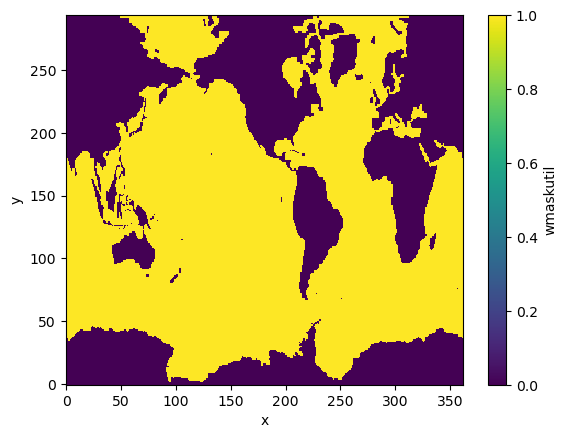

In [21]:
ds_domain['wmaskutil'][:, :].plot()

In [22]:
outfpath = "/g100_work/optim_IAC/research/noc/otooth/OptimESM/data/CNRM-ESM2-1/Ofx/eORCA1L75_domain_cfg_CNRM-ESM2-1.nc"
ds_domain.to_netcdf(outfpath)